# Deliverable 1

### Task 1

In [1]:
import locale
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import requests
from numpy import mean, median


def load_frost_key(path="../key_frost.py"):
    """Load API client ID from local file."""
    sys.path.append("..")
    with open(path, "r", encoding="utf-8") as file:
        return file.read().strip()


def get_frost_data(client_id, year):
    """Connctin to frost server and get the mean temperatur for 2025."""
    endpoint = "https://frost.met.no/observations/v0.jsonld"
    parameters = {
        "sources": "SN17850",
        "elements": "mean(air_temperature P1D)",
        "referencetime": f"{year}-01-01/{year}-12-31",
    }

    response = requests.get(
        endpoint,
        params=parameters,
        auth=(client_id, "")
    )
    response.raise_for_status()
    return response.json()["data"]


def get_the_rigth_format(data):
    """Collect the dates and temperatures from Frost API response and get the dates in right format."""
    dates = []
    temps = []

    for entry in data:
        date = entry["referenceTime"][:10]  # YYYY-MM-DD
        temp = entry["observations"][0]["value"]
        dates.append(date)
        temps.append(temp)

    df = pd.DataFrame({
        "Dato": pd.to_datetime(dates),
        "Temperatur": temps
    })
    df["Dag"] = df["Dato"].dt.dayofyear
    return df


def summary(df):
    """Creating a summary for min, max, mean and median temperatur."""
    min_temp = df["Temperatur"].min()
    max_temp = df["Temperatur"].max()
    mean_temp = mean(df["Temperatur"])
    median_temp = median(df["Temperatur"])

    min_date = df.loc[df["Temperatur"].idxmin(), "Dato"].date()
    
    max_date = df.loc[df["Temperatur"].idxmax(), "Dato"].date()
    print("Summary for 2025:\n")
    print(
        f"Lowest temperatur: {min_temp} °C, measured {min_date}\n"
        f"Max temperatur: {max_temp} °C, measured {max_date}"
    )
    print(f"Mean: {mean_temp:.1f} °C")
    print(f"Median: {median_temp:.1f} °C\n")



def plot_temperature(df):
    """Plot temperature series with Norwegian month labels."""
    plt.figure(figsize=(12, 5))
    plt.plot(df["Dato"], df["Temperatur"], marker="o", color="steelblue", linewidth=1.8, markersize=3)

    locale.setlocale(locale.LC_TIME, "nb_NO.UTF-8")

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    plt.xticks(rotation=0)
    plt.xlabel("Month")
    plt.ylabel("Temperatur (°C)")
    plt.title("Mean temperatur from SN17850 in 2025")
    plt.tight_layout()
    plt.show()


def main():
    """The main program that runs task 3 and collect the right data 
    and specifies which data each function shall use."""
    client_id = load_frost_key()
    data = get_frost_data_2025(client_id, 2025)
    df = get_the_rigth_format(data)
    plot_temperature(df)
    summary(df)

if __name__ == "__main__":
    main()


NameError: name 'get_frost_data_2025' is not defined

### Task 2

### Task 3

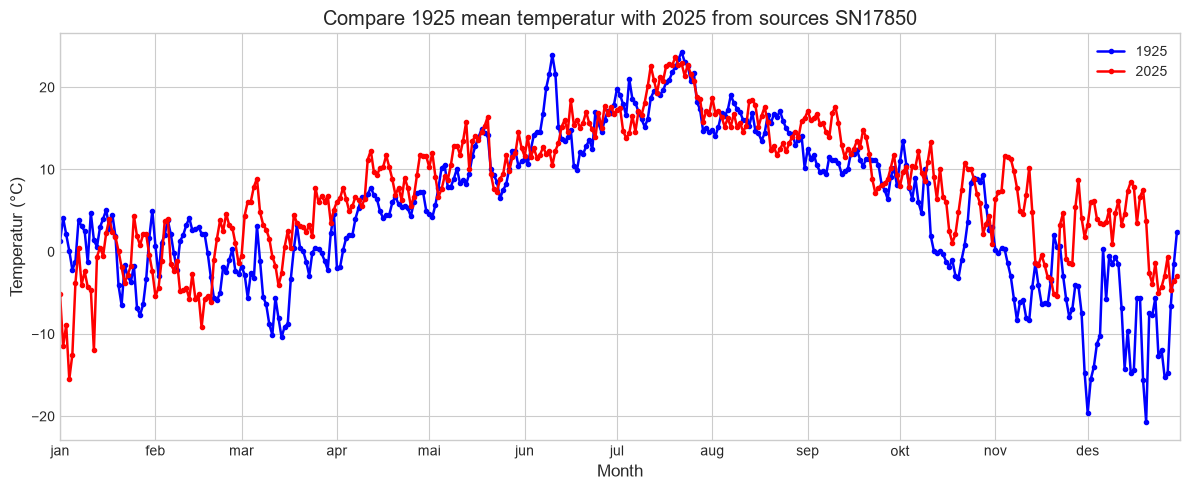

Summary for 1925:

Lowest temperatur: -20.7 °C, measured 1925-12-20
Max temperatur: 24.3 °C, measured 1925-07-22
Mean: 5.3 °C
Median: 5.3 °C

Summary for 2025:

Lowest temperatur: -15.5 °C, measured 2025-01-04
Max temperatur: 23.7 °C, measured 2025-07-20
Mean: 7.9 °C
Median: 8.4 °C



In [ ]:
def summary2(df):
    """Creating a summary for min, max, mean and median temperatur."""
    min_temp = df["Temperatur"].min()
    max_temp = df["Temperatur"].max()
    mean_temp = mean(df["Temperatur"])
    median_temp = median(df["Temperatur"])

    min_date = df.loc[df["Temperatur"].idxmin(), "Dato"].date()
    
    max_date = df.loc[df["Temperatur"].idxmax(), "Dato"].date()
    print("Summary for 1925:\n")
    print(
        f"Lowest temperatur: {min_temp} °C, measured {min_date}\n"
        f"Max temperatur: {max_temp} °C, measured {max_date}"
    )
    print(f"Mean: {mean_temp:.1f} °C")
    print(f"Median: {median_temp:.1f} °C\n")


def plot_2_temperature(df_year1, df_year2):
    """Plot temperature series with Norwegian month labels."""
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.figure(figsize=(12, 5))
    plt.plot(df_year1["Dag"], df_year1["Temperatur"], marker="o", label="1925", linewidth=1.8, markersize=3, color="b")
    plt.plot(df_year2["Dag"], df_year2["Temperatur"], marker="o", label="2025", linewidth=1.8, markersize=3, color="r")

    month_names = ("jan", "feb", "mar", "apr", "mai", "jun", "jul", "aug", "sep", "okt", "nov", "des")
    month_starts = (1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335)
    plt.xticks(month_starts, month_names)
    plt.xlim(1, 365)
    plt.xlabel("Month")
    plt.ylabel("Temperatur (°C)")
    plt.title("Compare 1925 mean temperatur with 2025 from sources SN17850")
    plt.legend()
    plt.tight_layout()
    plt.show()


def main():
    """The main program that runs task 3 and collect the right data 
    and specifies which data each function shall use."""
    client_id = load_frost_key()

    data_1925 = get_frost_data(client_id, 1925)
    data_2025 = get_frost_data(client_id, 2025)

    df_1925 = get_the_rigth_format(data_1925)
    df_2025 = get_the_rigth_format(data_2025)

    plot_2_temperature(df_1925, df_2025)
    summary2(df_1925)
    summary(df_2025)


if __name__ == "__main__":
    main()


### Task 4

In [2]:
import yaml


def get_frost_maxdata(client_id, station_id, year):
    """Connect to Frost API and define that we want the mean daily temperature for 1925."""
    endpoint = "https://frost.met.no/observations/v0.jsonld"
    parameters = {
        "sources": station_id,
        "elements": "max(air_temperature P1D)",
        "referencetime": f"{year}-01-01/{year}-12-31",
    }

    response = requests.get(endpoint, params=parameters, auth=(client_id, ""))
    response.raise_for_status()
    return response.json()["data"]


def heatwave (data):
    """Counting how many heatwaves there are in the current period.
    A heatwave is a periode with 5 or more days above 27°C."""
    
    heatwaves = []
    current_streak = []

    for entry in sorted(data, key=lambda item: item["referenceTime"]):
        day = entry["referenceTime"][:10]
        temp = entry["observations"][0]["value"]

        if temp >= 27:
            current_streak.append(day)
        else:
            if len(current_streak) >= 5:
                heatwaves.append(f"{current_streak[0]} - {current_streak[-1]}")
            current_streak = []

    if len(current_streak) >= 5:
        heatwaves.append(f"{current_streak[0]} - {current_streak[-1]}")

    return heatwaves


def yml_file(station_id, year, heatwaves):
    data = {
        "dates": heatwaves,
        "station": station_id,
        "year": year,
        "heatwave_count": len(heatwaves),
    }

    with open("heatwave_summary.yml", "w", encoding="utf-8") as output_file:
        yaml.safe_dump(data, output_file, sort_keys=False)


def main():
    """The main program that runs task 3 and collect the right data 
    and specifies which data each function shall use."""
    client_id = load_frost_key()
    station_id = "SN17850"
    year = 2025

    max_data = get_frost_maxdata(client_id, station_id, year)
    heatwaves = heatwave(max_data)
    yml_file(station_id, year, heatwaves)



if __name__ == "__main__":
    main()
    

### Task 5